# Messages

In [1]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

In [2]:
messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


# Chat Models

In [3]:
import os
from dotenv import load_dotenv

In [4]:
load_dotenv()

True

In [5]:
API_key = os.getenv("GOOGLE_API_KEY")

In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [7]:
llm_model = "gemini-2.5-flash"

In [15]:
model = ChatGoogleGenerativeAI(
    model=llm_model,
    temperature=0,
    max_tokens=1000,
    timeout=None,
    max_retries=2,
)

In [9]:
os.environ["LANGCHAIN_PROJECT"] = "simple Graph" # connect with LangSmith

In [12]:
result = model.invoke(messages)

In [13]:
type(result)

langchain_core.messages.ai.AIMessage

In [14]:
result

AIMessage(content='That\'s a fantastic goal! Orcas are incredible creatures to witness in the wild.\n\nWhen it comes to the "best" place to see Orcas in the US, it really boils down to two primary regions, each offering a slightly different experience:\n\n1.  **San Juan Islands, Washington State (Pacific Northwest)**\n    *   **Why it\'s often considered the best:** This area is famous for its **Southern Resident Killer Whales (SRKW)**, which are fish-eating orcas. While their presence has become less predictable in recent years due to salmon availability, the San Juan Islands still offer the highest chance of seeing orcas in the contiguous US, especially during peak season.\n    *   **Types of Orcas:** You\'ll primarily be looking for the Southern Residents (J, K, and L pods), but increasingly, **Bigg\'s (transient) orcas** (which eat marine mammals like seals and sea lions) are seen year-round in these waters. Bigg\'s orcas are actually becoming more reliable to spot than the residen

In [16]:
result.response_metadata

{'finish_reason': 'STOP',
 'model_name': 'gemini-2.5-flash',
 'safety_ratings': [],
 'model_provider': 'google_genai'}

# Tools 

In [17]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

In [18]:
model_with_tools = ChatGoogleGenerativeAI(
                    model=llm_model,
                    temperature=0,
                    max_tokens=1000,
                    timeout=None,
                    max_retries=2).bind_tools([multiply])

In [19]:
tool_call = model_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Lance")])

In [21]:
tool_call

AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}, '__gemini_function_call_thought_signatures__': {'dc75b5e1-85f5-46ac-9cc3-ddc8aa61863c': 'CoACAb4+9vujH8+SxmFz0Bj49m6lPxBzN1cFJ3CnhAQpR/eB1vs+n2/G2+7AZ+I+LKpL8S6VfVTLYKpSgmEFw00cRFTD5etc8EbTw12l1FTv0FeUU2ar8693xukEcqMgTYn+LXKZonOB7h7fSSYEQLtKZqqpu0EkZdqEULB2p/zHBwd45O7m6NOREPc3qzBqJHvdlCH7V5PWMhnjWCrm+sAa01ULymxBg6rBIn36bgHLNNZ3WiLq+QLS8pB/124l9NkmCej5A2zv65JZ3u39pmlo8ghvbP9+KFTeNWo74w1j0QxVkj3n6nBNQWZ7JfRYeLw+IaVU0/wh0d52QcsYu9SCjQ=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d21a5-3718-7173-a779-84332023575b-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'dc75b5e1-85f5-46ac-9cc3-ddc8aa61863c', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 57, 'output_tokens': 80, 'total_tokens': 137, 'input_token_details': {'cac

In [22]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'dc75b5e1-85f5-46ac-9cc3-ddc8aa61863c',
  'type': 'tool_call'}]

# Using messages as state

In [23]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

### using Reducers to append messages to our messages state key

In [24]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages] # the pre-built add_messages reducer.

## or 

In [26]:
from langgraph.graph import MessagesState #from langgraph 

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

In [27]:
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='df9d8ffe-ecda-4aa5-a765-0166da1c8f5d', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='7e86f728-8024-4b30-a988-b16526a34461'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='e0c65d1b-8a57-4bbc-95fa-2adfb20f4dc3', tool_calls=[], invalid_tool_calls=[])]

# Build Graph 

In [28]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    

In [29]:
def tool_calling_llm(state: MessagesState):
    return {"messages": [model_with_tools.invoke(state["messages"])]}

In [30]:
builder = StateGraph(MessagesState)

In [31]:
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)

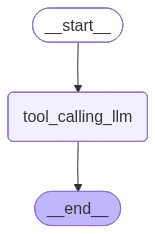

In [32]:
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [33]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! I am a large language model, able to perform various tasks. What can I do for you today?


In [34]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (347135de-d94a-4df6-9210-3edd87a49652)
 Call ID: 347135de-d94a-4df6-9210-3edd87a49652
  Args:
    a: 2
    b: 3
